# Priority Scoring Model: Collection Urgency Ranking

### Smart Waste Management System for Ghanaian Municipalities

**Objective:** Creating a scoring system that ranks bins by collection urgency, enabling optimized routing for waste collection trucks.

### Business Logic
Priority is determined by:
1. **Fill Level** — Higher fill = more urgent
2. **Waste Type** — Hazardous waste gets highest priority regardless of fill
3. **Days Since Collection** — Longer wait = more urgent
4. **Population Density** — High-traffic areas prioritized
5. **Overflow/Odor History** — Problem bins get attention

---

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from pathlib import Path 
import warnings
warnings.filterwarnings('ignore')

data_path = 'C:/Users/user/Desktop/DecisionTree/data/processed/features.csv'

In [3]:
df = pd.read_csv(data_path)

In [4]:
df.head()

,collection_id,bin_id,collection_date,collection_time,day_of_week,is_holiday,holiday_name,is_festival_period,festival_name,days_since_last_collection,...,fill_rate_7day_avg,fill_rate_7day_std,weight_7day_avg,prev_fill_level,prev_days_since_collection,bin_age_days,fill_rate_per_day,overflow_count_30day,organic_percent,recyclable_percent
0,COL_0000001,BIN_00001,2022-01-01,12:03,Saturday,1,New Year's Day,0,NaN,3,...,23.800000,0.000000,13.590000,35.07321,3.380041,2427,7.933333,0.0,52.2,17.4
1,COL_0000002,BIN_00001,2022-01-04,12:40,Tuesday,0,NaN,0,NaN,3,...,21.700000,2.969848,12.210000,23.80000,3.000000,2430,6.533333,0.0,52.2,17.4
2,COL_0000003,BIN_00001,2022-01-07,08:32,Friday,1,Constitution Day,0,NaN,3,...,22.366667,2.396525,11.793333,19.60000,3.000000,2433,7.900000,0.0,52.2,17.4
3,COL_0000004,BIN_00001,2022-01-10,13:28,Monday,0,NaN,0,NaN,3,...,22.325000,1.958528,12.135000,23.70000,3.000000,2436,7.400000,0.0,52.2,17.4
4,COL_0000005,BIN_00001,2022-01-14,14:57,Friday,0,NaN,0,NaN,4,...,24.220000,4.564209,13.754000,22.20000,3.000000,2440,7.950000,0.0,39.1,17.4


## 1. Rule-Baseed Priority Scoring System 

In [5]:
def calculate_priority_score(row):
    """
    Calculating the collection priority score (0-100).
    Higher score = more urgent collection needed.
    
    Weights based on municipal waste management priorities:
    - Public health (hazardous, overflow) = highest
    - Fill level = primary operational metric
    - Time since collection = secondary
    - Population impact = tertiary
    """
    score = 0
    
    # === COMPONENT 1: Fill Level (0-35 points) ===
    fill_pct = row['fill_level_percent']
    if fill_pct >= 90:
        score += 35  # Critical
    elif fill_pct >= 75:
        score += 28  # High
    elif fill_pct >= 50:
        score += 18  # Medium
    elif fill_pct >= 30:
        score += 8   # Low
    else:
        score += 2   # Minimal
    
    # === COMPONENT 2: Waste Type (0-30 points) ===
    waste_type = row['waste_type_primary']
    waste_scores = {
        'hazardous': 30,      # Always urgent - safety critical
        'e_waste': 20,        # Environmental concern
        'organic': 15,        # Decomposes, attracts pests
        'general': 10,        # Standard priority
        'recyclable': 8,      # Can wait slightly longer
        'construction': 5     # Inert, low urgency
    }
    score += waste_scores.get(waste_type, 10)
    
    # === COMPONENT 3: Days Since Collection (0-15 points) ===
    days = row['days_since_last_collection']
    if days >= 7:
        score += 15  # Week+ overdue
    elif days >= 5:
        score += 12
    elif days >= 4:
        score += 8
    elif days >= 3:
        score += 4
    else:
        score += 1
    
    # === COMPONENT 4: Population Impact (0-10 points) ===
    population = row['nearby_population']
    if population >= 3000:
        score += 10  # High density area
    elif population >= 1500:
        score += 7
    elif population >= 500:
        score += 4
    else:
        score += 1
    
    # === COMPONENT 5: Problem History (0-10 points) ===
    if row.get('overflow_reported', 0) == 1:
        score += 7  # Current overflow
    if row.get('odor_complaint', 0) == 1:
        score += 3  # Odor issue
    
    # Cap at 100
    return min(score, 100)

print("Priority scoring function defined!")

Priority scoring function defined!


In [6]:
# Applying  scoring to entire dataset
df['priority_score'] = df.apply(calculate_priority_score, axis=1)

# Create priority categories
def categorize_priority(score):
    if score >= 70:
        return 'CRITICAL'
    elif score >= 50:
        return 'HIGH'
    elif score >= 30:
        return 'MEDIUM'
    else:
        return 'LOW'

df['priority_category'] = df['priority_score'].apply(categorize_priority)

# Summary statistics
print("="*50)
print("PRIORITY SCORE DISTRIBUTION")
print("="*50)
print(f"\nScore Statistics:")
print(f"  Min:    {df['priority_score'].min():.0f}")
print(f"  Max:    {df['priority_score'].max():.0f}")
print(f"  Mean:   {df['priority_score'].mean():.1f}")
print(f"  Median: {df['priority_score'].median():.0f}")

print(f"\nPriority Categories:")
cat_counts = df['priority_category'].value_counts()
for cat in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
    count = cat_counts.get(cat, 0)
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"  {cat:10} | {count:6,} | {pct:5.1f}% | {bar}")

PRIORITY SCORE DISTRIBUTION

Score Statistics:
  Min:    12
  Max:    91
  Mean:   27.7
  Median: 25

Priority Categories:
  CRITICAL   |    567 |   0.5% | 
  HIGH       |  4,787 |   4.4% | ██
  MEDIUM     | 29,962 |  27.8% | █████████████
  LOW        | 72,633 |  67.3% | █████████████████████████████████


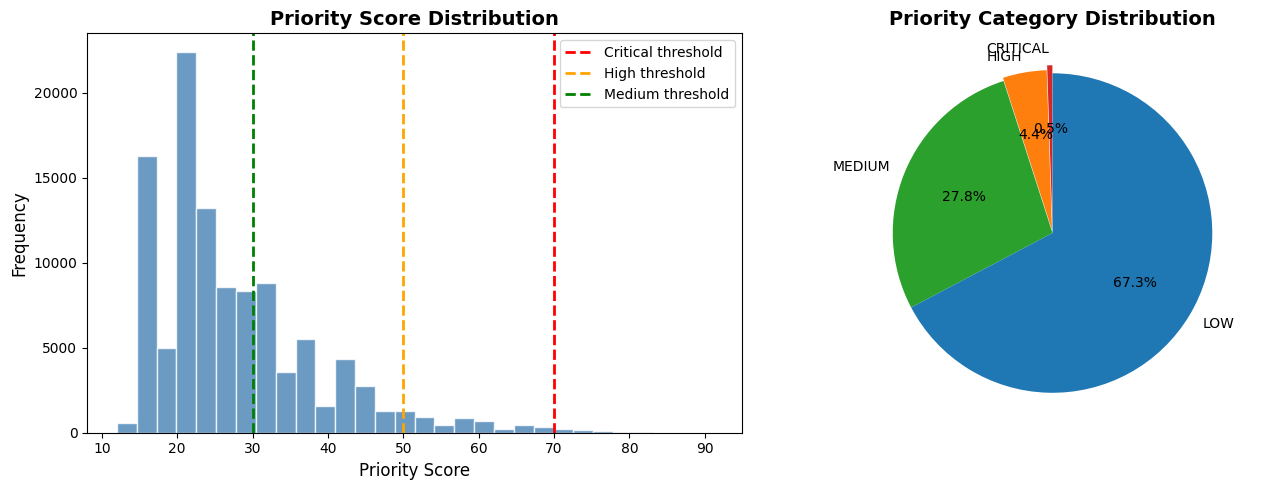

In [7]:
# Visualizing the  distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(df['priority_score'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(70, color='red', linestyle='--', linewidth=2, label='Critical threshold')
ax1.axvline(50, color='orange', linestyle='--', linewidth=2, label='High threshold')
ax1.axvline(30, color='green', linestyle='--', linewidth=2, label='Medium threshold')
ax1.set_xlabel('Priority Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Priority Score Distribution', fontsize=14, fontweight='bold')
ax1.legend()

# Category pie chart
ax2 = axes[1]
colors = {'CRITICAL': '#d62728', 
                'HIGH': '#ff7f0e', 
                'MEDIUM': '#2ca02c', 
                'LOW': '#1f77b4'}
cat_order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']
sizes = [cat_counts.get(c, 0) for c in cat_order]
ax2.pie(sizes, labels=cat_order, autopct='%1.1f%%', 
        colors=[colors[c] for c in cat_order], startangle=90,
        explode=[0.05, 0.02, 0, 0])
ax2.set_title('Priority Category Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/priority_score_distribution.png', 
                dpi=150, bbox_inches='tight')
plt.show()

## 2. Priority Analysis by Segment

In [9]:
# Priority by location type
print("="*60)
print("AVERAGE PRIORITY BY LOCATION TYPE")
print("="*60)

location_priority = df.groupby('location_type')['priority_score'].agg(['mean', 'std', 'count'])
location_priority = location_priority.sort_values('mean', ascending=False)

for loc, row in location_priority.iterrows():
    bar = '█' * int(row['mean'] / 2)
    print(f"{loc:15} | Mean: {row['mean']:5.1f} | Standard Deviation: {row['std']:5.1f} | {bar}")

AVERAGE PRIORITY BY LOCATION TYPE
market          | Mean:  44.6 | Standard Deviation:  12.5 | ██████████████████████
hospitality     | Mean:  35.9 | Standard Deviation:  11.2 | █████████████████
industrial      | Mean:  27.9 | Standard Deviation:  11.0 | █████████████
commercial      | Mean:  27.1 | Standard Deviation:   8.3 | █████████████
institutional   | Mean:  26.3 | Standard Deviation:   7.2 | █████████████
residential     | Mean:  22.1 | Standard Deviation:   5.9 | ███████████


In [10]:
# Priority by waste type
print("\n" + "="*60)
print("AVERAGE PRIORITY BY WASTE TYPE")
print("="*60)

waste_priority = df.groupby('waste_type_primary')['priority_score'].agg(['mean', 'std', 'count'])
waste_priority = waste_priority.sort_values('mean', ascending=False)

for wt, row in waste_priority.iterrows():
    bar = '█' * int(row['mean'] / 2)
    print(f"{wt:15} | Mean: {row['mean']:5.1f} | Standard Deviation: {row['std']:5.1f} | {bar}")


AVERAGE PRIORITY BY WASTE TYPE
hazardous       | Mean:  44.5 | Standard Deviation:   8.3 | ██████████████████████
e_waste         | Mean:  33.2 | Standard Deviation:   7.0 | ████████████████
organic         | Mean:  31.7 | Standard Deviation:  11.2 | ███████████████
general         | Mean:  24.6 | Standard Deviation:   8.8 | ████████████
recyclable      | Mean:  23.1 | Standard Deviation:   8.7 | ███████████
construction    | Mean:  19.9 | Standard Deviation:   8.5 | █████████


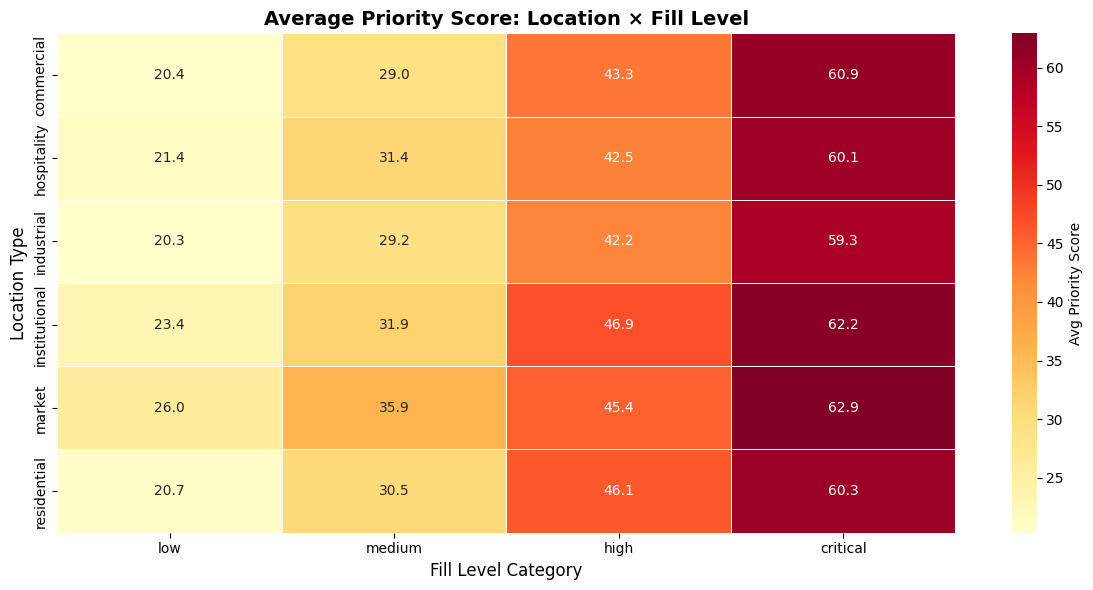

In [18]:
# Heatmap: Location vs Fill Level Category
fig, ax = plt.subplots(figsize=(12, 6))

pivot = df.pivot_table(
    values='priority_score', 
    index='location_type', 
    columns='fill_level_category',
    aggfunc='mean'
)

# Reorder columns
col_order = ['low', 'medium', 'high', 'critical']
pivot = pivot[[c for c in col_order if c in pivot.columns]]

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Priority Score'})
ax.set_title('Average Priority Score: Location × Fill Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Fill Level Category', fontsize=12)
ax.set_ylabel('Location Type', fontsize=12)

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/priority_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Dispatch Rule: Any bin at "critical" fill level scores 59+ regardless of location — prioritize these first. Markets and institutional locations at "high" fill (45-47) should be next in queue.

## 3. ML-Based Priority Model (Learning to Rank)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prepare features for ML model
feature_cols = [
    'fill_level_percent',
    'days_since_last_collection',
    'nearby_population',
    'capacity_liters',
    'distance_to_depot_km',
    'temperature_c',
    'is_weekend',
    'is_holiday',
    'overflow_reported',
    'odor_complaint'
]

# Encode categoricals
le_location = LabelEncoder()
le_waste = LabelEncoder()

df['location_encoded'] = le_location.fit_transform(df['location_type'])
df['waste_encoded'] = le_waste.fit_transform(df['waste_type_primary'])

feature_cols_ml = feature_cols + ['location_encoded', 'waste_encoded']

# Prepare X, y
X = df[feature_cols_ml].fillna(0)
y = df['priority_score']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Features: {len(feature_cols_ml)}")

Training samples: 86,359
Test samples: 21,590
Features: 12


In [14]:
# Train Gradient Boosting Regressor
print("="*50)
print("TRAINING GRADIENT BOOSTING REGRESSOR")
print("="*50)

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2 = r2_score(y_test, y_pred_gb)

print(f"\nGradient Boosting Results:")
print(f"  MAE:  {mae:.2f} points")
print(f"  RMSE: {rmse:.2f} points")
print(f"  R²:   {r2:.4f}")

TRAINING GRADIENT BOOSTING REGRESSOR

Gradient Boosting Results:
  MAE:  0.10 points
  RMSE: 0.19 points
  R²:   0.9997


In [15]:
# Train Random Forest for comparison
print("\n" + "="*50)
print("TRAINING RANDOM FOREST REGRESSOR")
print("="*50)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Results:")
print(f"  MAE:  {mae_rf:.2f} points")
print(f"  RMSE: {rmse_rf:.2f} points")
print(f"  R²:   {r2_rf:.4f}")


TRAINING RANDOM FOREST REGRESSOR

Random Forest Results:
  MAE:  0.05 points
  RMSE: 0.30 points
  R²:   0.9992


In [16]:
# Model comparison
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(f"{'Model':<25} | {'MAE':>8} | {'RMSE':>8} | {'R²':>8}")
print("-"*60)
print(f"{'Gradient Boosting':<25} | {mae:>8.2f} | {rmse:>8.2f} | {r2:>8.4f}")
print(f"{'Random Forest':<25} | {mae_rf:>8.2f} | {rmse_rf:>8.2f} | {r2_rf:>8.4f}")
print("="*60)

best_model = rf_model if r2_rf > r2 else gb_model
best_name = "Random Forest" if r2_rf > r2 else "Gradient Boosting"
print(f"\n✓ Best Model: {best_name}")


MODEL COMPARISON
Model                     |      MAE |     RMSE |       R²
------------------------------------------------------------
Gradient Boosting         |     0.10 |     0.19 |   0.9997
Random Forest             |     0.05 |     0.30 |   0.9992

✓ Best Model: Gradient Boosting


In [17]:
# Feature importance from best model
importance_df = pd.DataFrame({
    'feature': feature_cols_ml,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance for Priority Scoring:")
print("="*50)
for _, row in importance_df.iterrows():
    bar = '█' * int(row['importance'] * 40)
    print(f"{row['feature']:25} | {row['importance']:.3f} | {bar}")


Feature Importance for Priority Scoring:
fill_level_percent        | 0.750 | █████████████████████████████
waste_encoded             | 0.170 | ██████
days_since_last_collection | 0.044 | █
nearby_population         | 0.031 | █
overflow_reported         | 0.003 | 
odor_complaint            | 0.002 | 
location_encoded          | 0.000 | 
temperature_c             | 0.000 | 
distance_to_depot_km      | 0.000 | 
capacity_liters           | 0.000 | 
is_weekend                | 0.000 | 
is_holiday                | 0.000 | 


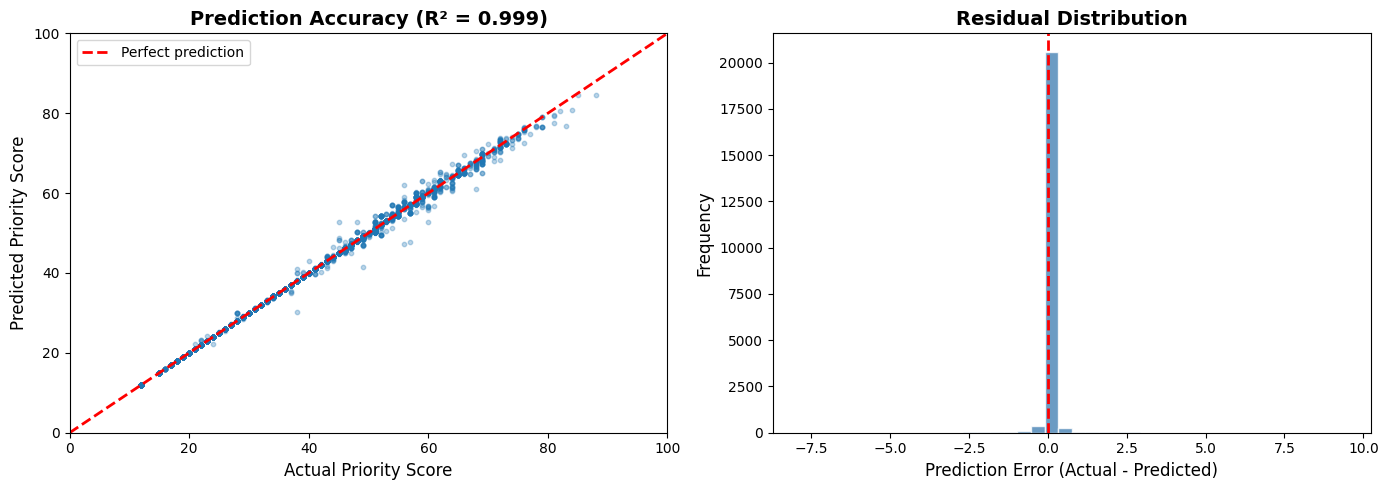

In [19]:
# Visualize predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax1 = axes[0]
ax1.scatter(y_test, y_pred_rf, alpha=0.3, s=10)
ax1.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual Priority Score', fontsize=12)
ax1.set_ylabel('Predicted Priority Score', fontsize=12)
ax1.set_title(f'Prediction Accuracy (R² = {r2_rf:.3f})', fontsize=14, fontweight='bold')
ax1.legend()
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)

# Residual distribution
ax2 = axes[1]
residuals = y_test - y_pred_rf
ax2.hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Residual Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/user/Desktop/DecisionTree/reports/figures/priority_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Insights 
The prediction results show that once a bin reaches full capacity, collection should happen immediately — no hesitation required. The model is accurate enough to act on without doubt.

## 4. Collection Route Optimization Demo

In [24]:
def get_daily_collection_priorities(df, date, top_n=20):
    """
    Get top priority bins for collection on a given date.
    Simulates what a dispatcher would see each morning.
    """
    # Filter to specific date
    daily = df[df['collection_date'] == date].copy()
    
    if len(daily) == 0:
        # Use most recent data as demo
        daily = df.tail(500).copy()
    
    # Sort by priority
    daily_sorted = daily.sort_values('priority_score', ascending=False)
    
    return daily_sorted.head(top_n)[[
        'bin_id', 'location_type', 'district', 
        'fill_level_percent', 'waste_type_primary',
        'days_since_last_collection', 'priority_score', 'priority_category'
    ]]

# Demo: Get today's priority list
print("="*80)
print(" DAILY COLLECTION PRIORITY LIST")
print("="*80)
print("Top 15 bins requiring immediate attention:\n")

priority_list = get_daily_collection_priorities(df, '2023-06-15', top_n=15)
print(priority_list.to_string(index=False))

 DAILY COLLECTION PRIORITY LIST
Top 15 bins requiring immediate attention:

   bin_id location_type      district  fill_level_percent waste_type_primary  days_since_last_collection  priority_score priority_category
BIN_00067   hospitality      Kaneshie                98.8            organic                           7              66              HIGH
BIN_00315    industrial    East Legon                64.6          hazardous                           7              64              HIGH
BIN_00483        market       Spintex                80.7            organic                           6              62              HIGH
BIN_00094        market      Dansoman                69.5            organic                           5              55              HIGH
BIN_00382        market Teshie-Nungua                62.4            organic                           4              51              HIGH
BIN_00357   hospitality         Kasoa                58.8            organic              

In [25]:
# Group by district for route planning
print("\n" + "="*60)
print(" PRIORITY BY DISTRICT (Route Planning)")
print("="*60)

district_summary = df.groupby('district').agg({
    'priority_score': 'mean',
    'bin_id': 'count',
    'overflow_reported': 'sum'
}).rename(columns={
    'priority_score': 'avg_priority',
    'bin_id': 'total_bins',
    'overflow_reported': 'overflow_count'
}).sort_values('avg_priority', ascending=False)

print(f"\n{'District':<20} | {'Avg Priority':>12} | {'Total Bins':>10} | {'Overflows':>10}")
print("-"*60)
for district, row in district_summary.head(10).iterrows():
    print(f"{district:<20} | {row['avg_priority']:>12.1f} | {row['total_bins']:>10,} | {row['overflow_count']:>10.0f}")


 PRIORITY BY DISTRICT (Route Planning)

District             | Avg Priority | Total Bins |  Overflows
------------------------------------------------------------
Kaneshie             |         30.4 |    5,600.0 |         52
Osu                  |         28.9 |    4,766.0 |         69
Tema                 |         28.4 |    9,317.0 |        120
Teshie-Nungua        |         28.4 |    6,696.0 |         71
Kasoa                |         28.1 |    7,736.0 |         48
Spintex              |         28.0 |    7,978.0 |         80
Ashaiman             |         28.0 |    6,053.0 |         39
Accra Central        |         27.8 |    6,452.0 |         31
Achimota             |         27.7 |    7,589.0 |         78
La                   |         27.6 |    9,491.0 |         80


In [23]:
def score_bin_priority(bin_data):
    """
    Production-ready function to score a single bin's collection priority.
    
    Parameters:
    -----------
    bin_data : dict
        Dictionary containing bin attributes:
        - fill_level_percent (float): 0-100
        - waste_type_primary (str): organic, recyclable, general, hazardous, e_waste, construction
        - days_since_last_collection (int): 0+
        - nearby_population (int): population count
        - overflow_reported (int): 0 or 1
        - odor_complaint (int): 0 or 1
    
    Returns:
    --------
    dict: Score, category, and component breakdown
    """
    components = {}
    
    # Fill level component
    fill = bin_data.get('fill_level_percent', 0)
    if fill >= 90: components['fill_level'] = 35
    elif fill >= 75: components['fill_level'] = 28
    elif fill >= 50: components['fill_level'] = 18
    elif fill >= 30: components['fill_level'] = 8
    else: components['fill_level'] = 2
    
    # Waste type component
    waste_scores = {'hazardous': 30, 'e_waste': 20, 'organic': 15, 
                    'general': 10, 'recyclable': 8, 'construction': 5}
    components['waste_type'] = waste_scores.get(bin_data.get('waste_type_primary', 'general'), 10)
    
    # Days component
    days = bin_data.get('days_since_last_collection', 0)
    if days >= 7: components['days_overdue'] = 15
    elif days >= 5: components['days_overdue'] = 12
    elif days >= 4: components['days_overdue'] = 8
    elif days >= 3: components['days_overdue'] = 4
    else: components['days_overdue'] = 1
    
    # Population component
    pop = bin_data.get('nearby_population', 0)
    if pop >= 3000: components['population'] = 10
    elif pop >= 1500: components['population'] = 7
    elif pop >= 500: components['population'] = 4
    else: components['population'] = 1
    
    # Problem history
    components['overflow'] = 7 if bin_data.get('overflow_reported', 0) else 0
    components['odor'] = 3 if bin_data.get('odor_complaint', 0) else 0
    
    # Total score
    total = min(sum(components.values()), 100)
    
    # Category
    if total >= 70: category = 'CRITICAL'
    elif total >= 50: category = 'HIGH'
    elif total >= 30: category = 'MEDIUM'
    else: category = 'LOW'
    
    return {
        'priority_score': total,
        'priority_category': category,
        'components': components,
        'recommendation': get_recommendation(category, bin_data.get('waste_type_primary'))
    }

def get_recommendation(category, waste_type):
    """Get actionable recommendation based on priority."""
    if waste_type == 'hazardous':
        return "⚠️ HAZARDOUS: Dispatch specialized team with PPE immediately"
    if category == 'CRITICAL':
        return "🔴 Collect within 4 hours - overflow risk"
    if category == 'HIGH':
        return "🟠 Collect today - approaching capacity"
    if category == 'MEDIUM':
        return "🟡 Schedule for tomorrow"
    return "🟢 Routine collection - can wait 2-3 days"

print("Priority scoring API ready!")

Priority scoring API ready!


In [26]:
# Test the API with examples
test_cases = [
    {
        'name': 'Critical Industrial Bin',
        'data': {
            'fill_level_percent': 95,
            'waste_type_primary': 'hazardous',
            'days_since_last_collection': 6,
            'nearby_population': 200,
            'overflow_reported': 1,
            'odor_complaint': 0
        }
    },
    {
        'name': 'Busy Market Bin',
        'data': {
            'fill_level_percent': 78,
            'waste_type_primary': 'organic',
            'days_since_last_collection': 4,
            'nearby_population': 5000,
            'overflow_reported': 0,
            'odor_complaint': 1
        }
    },
    {
        'name': 'Quiet Residential Bin',
        'data': {
            'fill_level_percent': 25,
            'waste_type_primary': 'general',
            'days_since_last_collection': 2,
            'nearby_population': 300,
            'overflow_reported': 0,
            'odor_complaint': 0
        }
    }
]

print("="*70)
print("PRIORITY SCORING API - TEST CASES")
print("="*70)

for case in test_cases:
    result = score_bin_priority(case['data'])
    print(f"\n📍 {case['name']}")
    print(f"   Score: {result['priority_score']} ({result['priority_category']})")
    print(f"   Breakdown: {result['components']}")
    print(f"   → {result['recommendation']}")

PRIORITY SCORING API - TEST CASES

📍 Critical Industrial Bin
   Score: 85 (CRITICAL)
   Breakdown: {'fill_level': 35, 'waste_type': 30, 'days_overdue': 12, 'population': 1, 'overflow': 7, 'odor': 0}
   → ⚠️ HAZARDOUS: Dispatch specialized team with PPE immediately

📍 Busy Market Bin
   Score: 64 (HIGH)
   Breakdown: {'fill_level': 28, 'waste_type': 15, 'days_overdue': 8, 'population': 10, 'overflow': 0, 'odor': 3}
   → 🟠 Collect today - approaching capacity

📍 Quiet Residential Bin
   Score: 14 (LOW)
   Breakdown: {'fill_level': 2, 'waste_type': 10, 'days_overdue': 1, 'population': 1, 'overflow': 0, 'odor': 0}
   → 🟢 Routine collection - can wait 2-3 days


In [28]:
import joblib
from datetime import datetime
import json

# Save ML model
model_path = 'C:/Users/user/Desktop/DecisionTree/models/priority_scoring_rf.joblib'
joblib.dump(rf_model, model_path)
print(f"✓ Model saved: {model_path}")

# Save encoders
encoders_path = 'C:/Users/user/Desktop/DecisionTree/models/priority_encoders.joblib'
joblib.dump({
    'location_encoder': le_location,
    'waste_encoder': le_waste,
    'feature_names': feature_cols_ml
}, encoders_path)
print(f"✓ Encoders saved: {encoders_path}")

# Save metrics
metrics = {
    'model_name': 'Priority Scoring Random Forest',
    'created': datetime.now().isoformat(),
    'metrics': {
        'mae': float(mae_rf),
        'rmse': float(rmse_rf),
        'r2': float(r2_rf)
    },
    'features': feature_cols_ml,
    'score_range': '0-100',
    'categories': ['LOW (0-29)', 'MEDIUM (30-49)', 'HIGH (50-69)', 'CRITICAL (70-100)']
}

with open('C:/Users/user/Desktop/DecisionTree/models/priority_scoring_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"✓ Metrics saved: C:/Users/user/Desktop/DecisionTree/models/priority_scoring_metrics.json")

✓ Model saved: C:/Users/user/Desktop/DecisionTree/models/priority_scoring_rf.joblib
✓ Encoders saved: C:/Users/user/Desktop/DecisionTree/models/priority_encoders.joblib
✓ Metrics saved: C:/Users/user/Desktop/DecisionTree/models/priority_scoring_metrics.json


In [29]:
# Export priority-scored dataset
export_cols = [
    'collection_id', 'bin_id', 'collection_date', 'location_type', 'district',
    'fill_level_percent', 'fill_level_category', 'waste_type_primary',
    'days_since_last_collection', 'nearby_population',
    'overflow_reported', 'odor_complaint',
    'priority_score', 'priority_category'
]

df[export_cols].to_csv('C:/Users/user/Desktop/DecisionTree/data/processed/collections_with_priority.csv', index=False)
print(f"✓ Priority-scored data exported: C:/Users/user/Desktop/DecisionTree/data/processed/collections_with_priority.csv")

✓ Priority-scored data exported: C:/Users/user/Desktop/DecisionTree/data/processed/collections_with_priority.csv


In [31]:
print("""
══════════════════════════════════════════════════════════════════════════════
           PRIORITY SCORING MODEL - COMPLETE

📊 RULE-BASED SCORING SYSTEM:
   • Fill Level:        0-35 points (35% weight)
   • Waste Type:        0-30 points (30% weight) - Hazardous = max
   • Days Overdue:      0-15 points (15% weight)
   • Population:        0-10 points (10% weight)
   • Problem History:   0-10 points (10% weight)

📈 ML MODEL PERFORMANCE:""")
print(f"   • Random Forest R²: {r2_rf:.4f}")
print(f"   • Mean Absolute Error: {mae_rf:.2f} points")
print(f"   • RMSE: {rmse_rf:.2f} points")

print("""
🎯 PRIORITY CATEGORIES:
   • CRITICAL (70-100): Immediate dispatch required
   • HIGH (50-69):      Collect within same day
   • MEDIUM (30-49):    Schedule for next day
   • LOW (0-29):        Routine collection cycle

📁 SAVED ARTIFACTS:
   • models/priority_scoring_rf.joblib
   • models/priority_encoders.joblib
   • models/priority_scoring_metrics.json
   • data/processed/collections_with_priority.csv
   • reports/figures/priority_*.png

✅ Ready for integration with route optimization system!
""")


══════════════════════════════════════════════════════════════════════════════
           PRIORITY SCORING MODEL - COMPLETE

📊 RULE-BASED SCORING SYSTEM:
   • Fill Level:        0-35 points (35% weight)
   • Waste Type:        0-30 points (30% weight) - Hazardous = max
   • Days Overdue:      0-15 points (15% weight)
   • Population:        0-10 points (10% weight)
   • Problem History:   0-10 points (10% weight)

📈 ML MODEL PERFORMANCE:
   • Random Forest R²: 0.9992
   • Mean Absolute Error: 0.05 points
   • RMSE: 0.30 points

🎯 PRIORITY CATEGORIES:
   • CRITICAL (70-100): Immediate dispatch required
   • HIGH (50-69):      Collect within same day
   • MEDIUM (30-49):    Schedule for next day
   • LOW (0-29):        Routine collection cycle

📁 SAVED ARTIFACTS:
   • models/priority_scoring_rf.joblib
   • models/priority_encoders.joblib
   • models/priority_scoring_metrics.json
   • data/processed/collections_with_priority.csv
   • reports/figures/priority_*.png

✅ Ready for integratio